<a href="https://colab.research.google.com/github/buvho/Colab-analise-de-dados-ibge/blob/main/atividade_geopandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando informações de desmatamento de agosto e setembro, e os municipios de minas gerais

In [ ]:
import pandas as pd
import geopandas as gpd

ago_gdf = gpd.read_file("https://github.com/terra-q/data-scientist-test-jan-2024/raw/refs/heads/main/dados/desmatamento_ago22.gpkg").to_crs(epsg=31983)
set_gdf = gpd.read_file("https://github.com/terra-q/data-scientist-test-jan-2024/raw/refs/heads/main/dados/desmatamento_set22.gpkg").to_crs(epsg=31983)
ago_gdf['mes'] = 'ago'
set_gdf['mes'] = 'set'
municipios_gdf = gpd.read_file('https://raw.githubusercontent.com/tbrugz/geodata-br/master/geojson/geojs-31-mun.json').to_crs(epsg=31983)
desmatamento_gdf = pd.concat([ago_gdf, set_gdf], ignore_index=True)


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:198: RuntimeWarning: unable to open database file: this file is a WAL-enabled database. It cannot be opened because it is presumably read-only or in a read-only directory. Retrying with IMMUTABLE=YES open option
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:198: RuntimeWarning: unable to open database file: this file is a WAL-enabled database. It cannot be opened because it is presumably read-only or in a read-only directory. Retrying with IMMUTABLE=YES open option
  return ogr_read(


Cálculando a área em km² de cada municipio

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd

municipios_gdf["area_km2"] = np.round(municipios_gdf.geometry.area / 10**6, 2)
print(municipios_gdf.head(10))

        id                 name          description  \
0  3100104  Abadia dos Dourados  Abadia dos Dourados   
1  3100203               Abaeté               Abaeté   
2  3100302           Abre Campo           Abre Campo   
3  3100401              Acaiaca              Acaiaca   
4  3100500              Açucena              Açucena   
5  3100609             Água Boa             Água Boa   
6  3100708        Água Comprida        Água Comprida   
7  3100807              Aguanil              Aguanil   
8  3100906       Águas Formosas       Águas Formosas   
9  3101003      Águas Vermelhas      Águas Vermelhas   

                                            geometry  area_km2  
0  POLYGON ((241429.802 7990562.876, 242359.697 7...    895.12  
1  POLYGON ((480831.209 7911603.048, 481764.623 7...   1814.50  
2  POLYGON ((775002.321 7771717.815, 776244.59 77...    472.05  
3  POLYGON ((696872.185 7747792.052, 697305.64 77...    100.72  
4  POLYGON ((775332.208 7905556.756, 775804.655 7...    81

Importando tabela do PIB de cada municipio e filtrando as informações

In [ ]:
import requests
import zipfile
import io
import pandas as pd

response = requests.get("https://ftp.ibge.gov.br/Pib_Municipios/2021/base/base_de_dados_2010_2021_xlsx.zip")
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
  excel_name = z.namelist()[0]
  with z.open(excel_name) as f:
    pib_df = pd.read_excel(f)

pib_df = pib_df[(pib_df['Ano'] == 2021) & (pib_df['Sigla da Unidade da Federação'] == 'MG')]
print(pib_df.head())


        Ano  Código da Grande Região Nome da Grande Região  \
63499  2021                        3               Sudeste   
63500  2021                        3               Sudeste   
63501  2021                        3               Sudeste   
63502  2021                        3               Sudeste   
63503  2021                        3               Sudeste   

       Código da Unidade da Federação Sigla da Unidade da Federação  \
63499                              31                            MG   
63500                              31                            MG   
63501                              31                            MG   
63502                              31                            MG   
63503                              31                            MG   

      Nome da Unidade da Federação  Código do Município    Nome do Município  \
63499                 Minas Gerais              3100104  Abadia dos Dourados   
63500                 Minas Gerais      

Selecionando somente as colunas necessárias

In [ ]:
import pandas as pd
import numpy as np

informacoes_relevantes = ['Código do Município',
                          'Produto Interno Bruto, \na preços correntes\n(R$ 1.000)',
                          'Produto Interno Bruto per capita, \na preços correntes\n(R$ 1,00)',
                          'Atividade com maior valor adicionado bruto',
                          'Valor adicionado bruto da Agropecuária, \na preços correntes\n(R$ 1.000)',
                          'Valor adicionado bruto da Indústria,\na preços correntes\n(R$ 1.000)',
                          'Valor adicionado bruto dos Serviços,\na preços correntes \n- exceto Administração, defesa, educação e saúde públicas e seguridade social\n(R$ 1.000)']
pib_df = pib_df[informacoes_relevantes]

pib_df.columns = ['codigo_municipio', 'PIB', 'PIB_per_capita','maior_VAB', 'VAB_agro', 'VAB_ind', 'VAB_serv']

KeyError: "None of [Index(['Código do Município',\n       'Produto Interno Bruto, \\na preços correntes\\n(R$ 1.000)',\n       'Produto Interno Bruto per capita, \\na preços correntes\\n(R$ 1,00)',\n       'Atividade com maior valor adicionado bruto',\n       'Valor adicionado bruto da Agropecuária, \\na preços correntes\\n(R$ 1.000)',\n       'Valor adicionado bruto da Indústria,\\na preços correntes\\n(R$ 1.000)',\n       'Valor adicionado bruto dos Serviços,\\na preços correntes \\n- exceto Administração, defesa, educação e saúde públicas e seguridade social\\n(R$ 1.000)'],\n      dtype='object')] are in the [columns]"

Importando tabela da população de cada municipio e filtrando as informações

In [ ]:
import pandas as pd
populacao_df = pd.read_csv('https://basedosdados.org/api/tables/downloadTable?p=YnJfaWJnZV9wb3B1bGFjYW8=&q=bXVuaWNpcGlv&d=dHJ1ZQ==&s=ZnJIZQ==', compression='gzip')
populacao_df = populacao_df[ (populacao_df['ano'] == 2022) & (populacao_df['sigla_uf'] == 'MG')]

print(populacao_df.columns)


Index(['ano', 'sigla_uf', 'id_municipio', 'populacao'], dtype='object')


Juntando os dataframes de PIB, população e municipios em um só

In [ ]:
import pandas as pd
populacao_pib_df = pd.merge(populacao_df, pib_df, left_on='id_municipio', right_on='codigo_municipio')
populacao_pib_df = populacao_pib_df.drop(columns=['codigo_municipio', 'ano', 'sigla_uf'],)
populacao_pib_df['id_municipio'] = populacao_pib_df['id_municipio'].astype(int).astype(str)
merged_gdf = municipios_gdf.merge(populacao_pib_df, left_on='id', right_on='id_municipio',how='left')
merged_gdf = merged_gdf.drop(columns=['id_municipio', 'description'])
merged_gdf = merged_gdf.rename(columns={'name': 'nome_municipio'})
print(merged_gdf)

          id          nome_municipio  \
0    3100104     Abadia dos Dourados   
1    3100203                  Abaeté   
2    3100302              Abre Campo   
3    3100401                 Acaiaca   
4    3100500                 Açucena   
..       ...                     ...   
848  3171808            Virginópolis   
849  3171907             Virgolândia   
850  3172004  Visconde do Rio Branco   
851  3172103            Volta Grande   
852  3172202          Wenceslau Braz   

                                              geometry  area_km2  populacao  \
0    POLYGON ((241429.802 7990562.876, 242359.697 7...    895.12     6235.0   
1    POLYGON ((480831.209 7911603.048, 481764.623 7...   1814.50    22492.0   
2    POLYGON ((775002.321 7771717.815, 776244.59 77...    472.05    13882.0   
3    POLYGON ((696872.185 7747792.052, 697305.64 77...    100.72     3920.0   
4    POLYGON ((775332.208 7905556.756, 775804.655 7...    812.88     9229.0   
..                                           

Cortando as áreas de desmatamento acordo com os municipios, os categorizando e cálculando área em km² de desmatamento

In [ ]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

desmatamento_gdf = gpd.overlay(
    desmatamento_gdf, merged_gdf[['nome_municipio', 'geometry']],
    how='intersection'
)
desmatamento_gdf["Area_desmatada_km2"] = np.round(desmatamento_gdf.geometry.area / 10**6, 10)

print(desmatamento_gdf.head(10))

   ogc_fid    id  Instância Data Inicial  Data Final   Cena Score  \
0      1.0  6726       9696   26/07/2022  05/08/2022  22KFC   0.9   
1      2.0  6727       9700   21/07/2022  26/07/2022  22KFD   0.9   
2      3.0  6728       9701   21/07/2022  26/07/2022  22KFD   0.9   
3      4.0  6729       9702   21/07/2022  05/08/2022  22KFD  0.93   
4      5.0  6730       9703   21/07/2022  05/08/2022  22KFD  0.91   
5      6.0  6731       9705   26/07/2022  05/08/2022  22KFD  0.91   
6      7.0  6732       9706   26/07/2022  05/08/2022  22KFD  0.92   
7      8.0  6733       9709   21/07/2022  26/07/2022  22KFE  0.92   
8      9.0  6734       9710   21/07/2022  26/07/2022  22KFE  0.91   
9     10.0  6735       9711   21/07/2022  26/07/2022  22KFE  0.91   

  Data Processamento           Bioma              NuFis Cia PM  mes  \
0   08/08/2022 13:08         Cerrado  Triângulo Mineiro      5  ago   
1   08/08/2022 13:08         Cerrado  Triângulo Mineiro      5  ago   
2   08/08/2022 13:08       

Criando gráficos de pizza (bioma,mes e desmatamento)

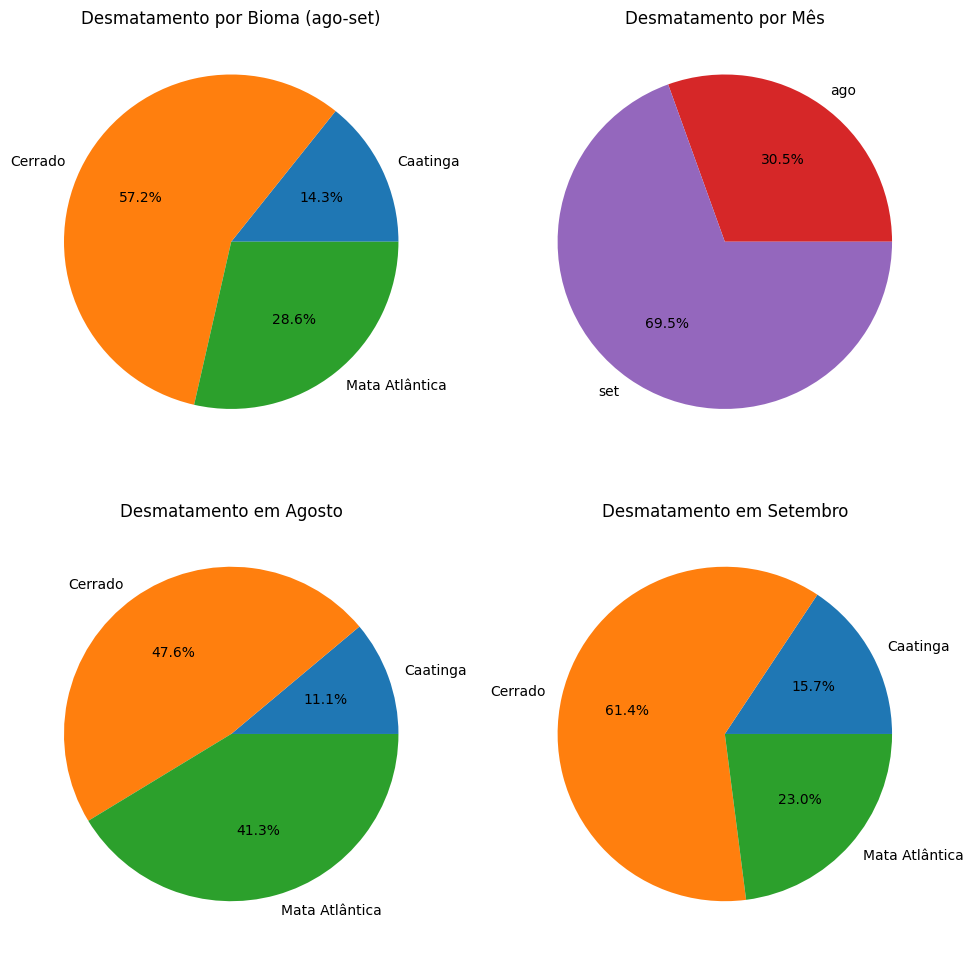

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

por_bioma = desmatamento_gdf.groupby('Bioma')['Area_desmatada_km2'].sum()
por_mes = desmatamento_gdf.groupby('mes')['Area_desmatada_km2'].sum()
por_bioma_ago = desmatamento_gdf[desmatamento_gdf['mes'] == 'ago'].groupby('Bioma')['Area_desmatada_km2'].sum()
por_bioma_set = desmatamento_gdf[desmatamento_gdf['mes'] == 'set'].groupby('Bioma')['Area_desmatada_km2'].sum()

fig, axes = plt.subplots(2, 2, figsize=(10,10))

axes[0,0].pie(por_bioma, labels=por_bioma.index, autopct='%1.1f%%')
axes[0,0].set_title('Desmatamento por Bioma (ago-set)')

axes[0,1].pie(por_mes, labels=por_mes.index, autopct='%1.1f%%', colors=['#d62728','#9467bd'])
axes[0,1].set_title('Desmatamento por Mês')

axes[1,0].pie(por_bioma_ago, labels=por_bioma_ago.index, autopct='%1.1f%%')
axes[1,0].set_title('Desmatamento em Agosto')

axes[1,1].pie(por_bioma_set, labels=por_bioma_set.index, autopct='%1.1f%%')
axes[1,1].set_title('Desmatamento em Setembro')

plt.tight_layout()
plt.show()

Gráfico de pizza (bioma e mês)

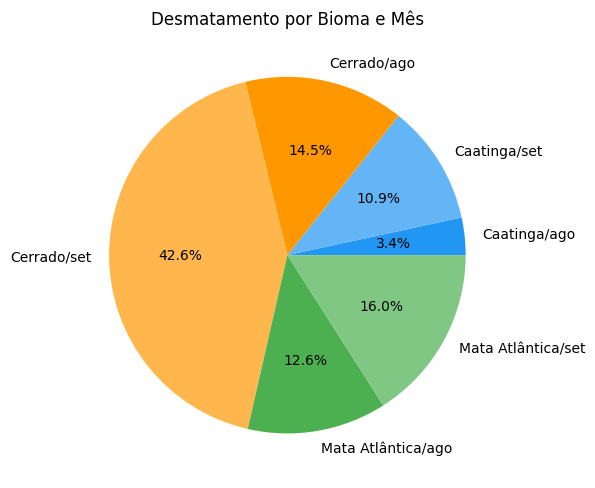

Bioma           mes
Caatinga        ago     13.916586
                set     44.755180
Cerrado         ago     59.663487
                set    175.278333
Mata Atlântica  ago     51.793794
                set     65.602703
Name: Area_desmatada_km2, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

por_bioma_mes = desmatamento_gdf.groupby(['Bioma','mes'])['Area_desmatada_km2'].sum()
por_bioma_mes = por_bioma_mes[por_bioma_mes > 0]
colors = [
    '#2196F3', '#64B5F6',  # azul escuro + azul claro
    '#FF9800', '#FFB74D',   # laranja escuro + laranja claro
    '#4CAF50', '#81C784',  # verde escuro + verde claro
]

labels = [
    'Caatinga/ago', 'Caatinga/set',
    'Cerrado/ago','Cerrado/set',
    'Mata Atlântica/ago', 'Mata Atlântica/set'
]

plt.figure(figsize=(6,6))
plt.pie(por_bioma_mes, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title('Desmatamento por Bioma e Mês')

plt.tight_layout()
plt.show()

print(por_bioma_mes)

Agrupando as áreas desmtadas por município e a acrescentando no gdf com os municípios

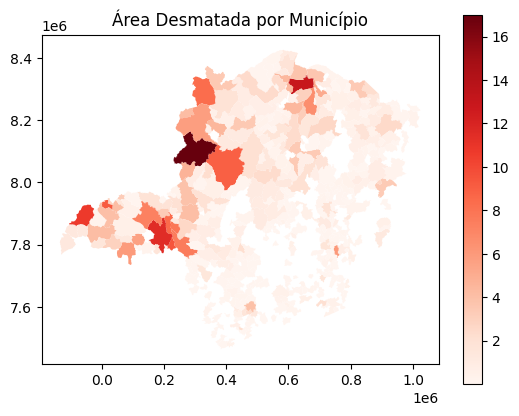

In [ ]:
import matplotlib.pyplot as plt

desmatamento_por_muncipio = desmatamento_gdf.groupby('nome_municipio')['Area_desmatada_km2'].sum()
merged_gdf['area_desmatada_km2'] = merged_gdf['nome_municipio'].map(desmatamento_por_muncipio)
merged_gdf.plot(column='area_desmatada_km2', cmap='Reds', legend=True)
plt.title('Área Desmatada por Município')
plt.show()

Mapas (area desmatada, populac, pib e pib per capita

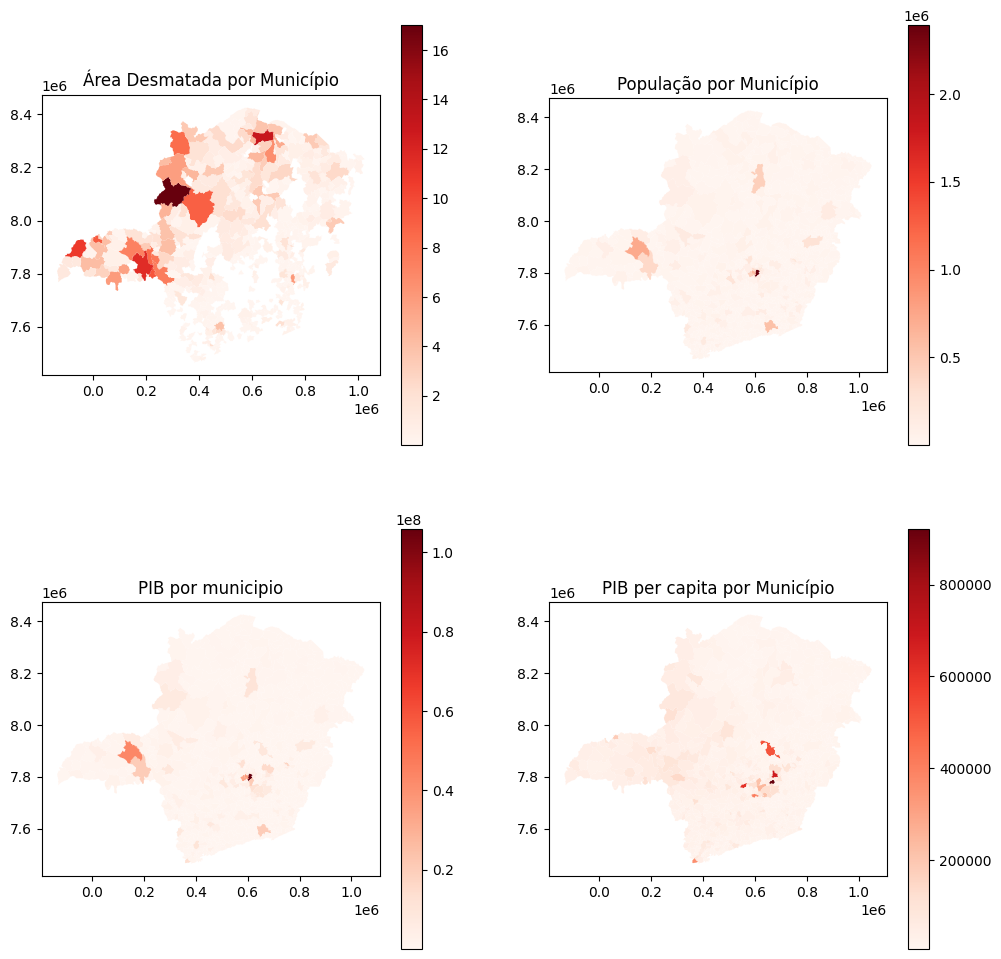

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,12))

merged_gdf.plot(column='area_desmatada_km2', cmap='Reds', legend=True, ax=axes[0,0])
axes[0,0].set_title('Área Desmatada por Município')

merged_gdf.plot(column='populacao', cmap='Reds', legend=True, ax=axes[0,1])
axes[0,1].set_title('População por Município')

merged_gdf.plot(column='PIB', cmap='Reds', legend=True, ax=axes[1,0])
axes[1,0].set_title('PIB por municipio')

merged_gdf.plot(column='PIB_per_capita', cmap='Reds', legend=True, ax=axes[1,1])
axes[1,1].set_title('PIB per capita por Município')

plt.show()

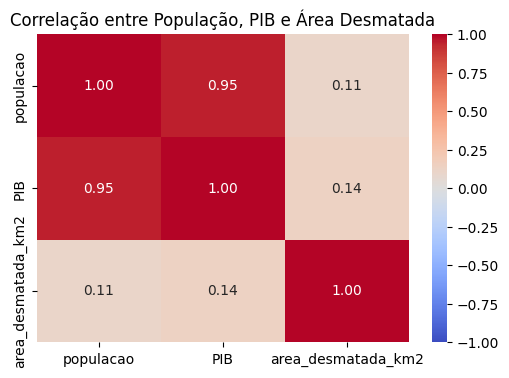

In [ ]:
corr = merged_gdf[['populacao', 'PIB', 'area_desmatada_km2']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1,   # escala fixa de correlação
)
plt.title('Correlação entre População, PIB e Área Desmatada')
plt.show()

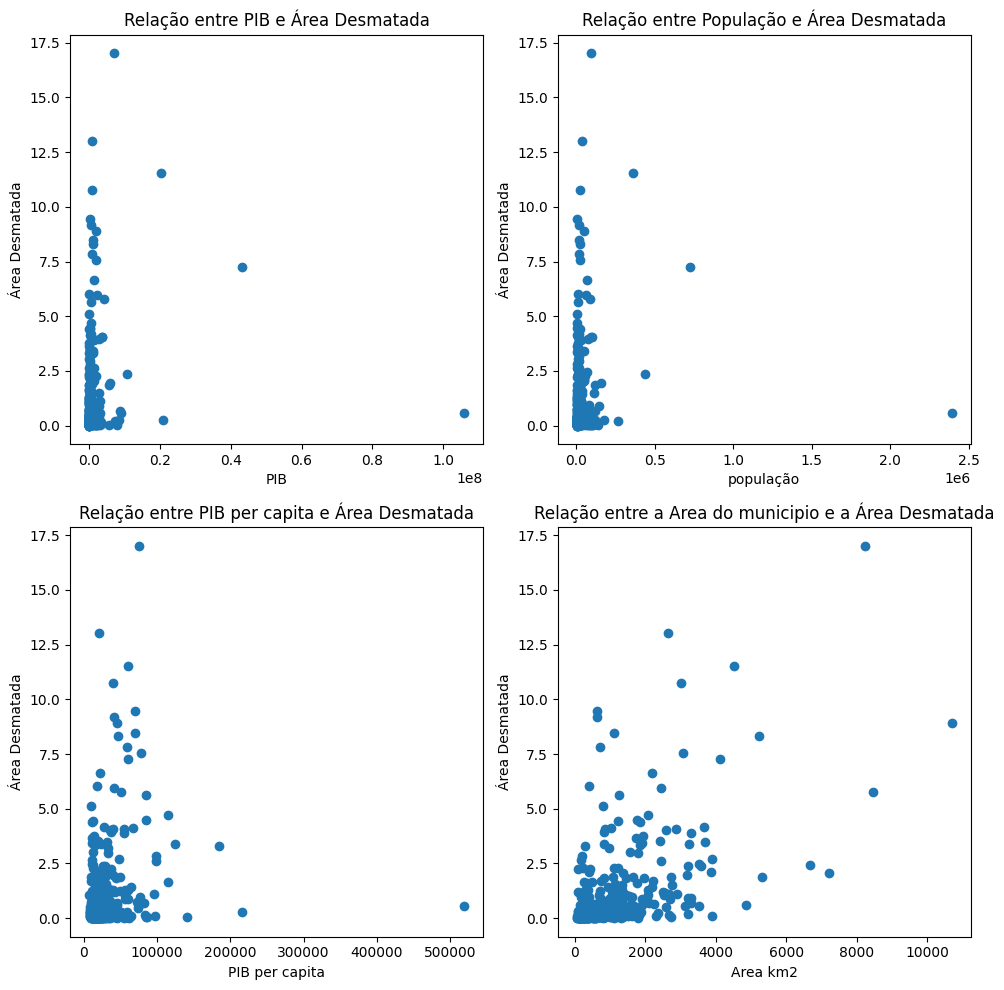

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))

axes[0,0].scatter(merged_gdf['PIB'], merged_gdf['area_desmatada_km2'])
axes[0,0].set_xlabel('PIB')
axes[0,0].set_ylabel('Área Desmatada')
axes[0,0].set_title('Relação entre PIB e Área Desmatada')

axes[0,1].scatter(merged_gdf['populacao'], merged_gdf['area_desmatada_km2'])
axes[0,1].set_xlabel('população')
axes[0,1].set_ylabel('Área Desmatada')
axes[0,1].set_title('Relação entre População e Área Desmatada')

axes[1,0].scatter(merged_gdf['PIB_per_capita'], merged_gdf['area_desmatada_km2'])
axes[1,0].set_xlabel('PIB per capita')
axes[1,0].set_ylabel('Área Desmatada')
axes[1,0].set_title('Relação entre PIB per capita e Área Desmatada')

axes[1,1].scatter(merged_gdf['area_km2'], merged_gdf['area_desmatada_km2'])
axes[1,1].set_xlabel('Area km2')
axes[1,1].set_ylabel('Área Desmatada')
axes[1,1].set_title('Relação entre a Area do municipio e a Área Desmatada')

plt.tight_layout()
plt.show()

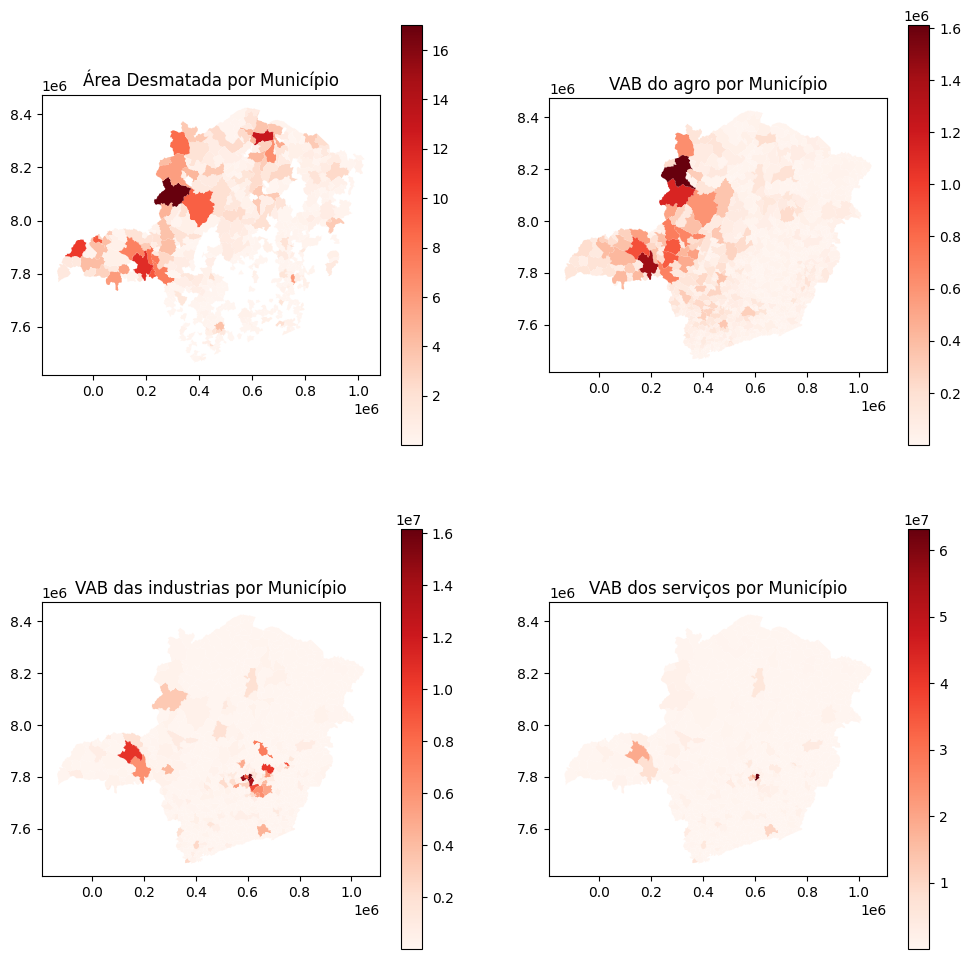

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,12))

merged_gdf.plot(column='area_desmatada_km2', cmap='Reds', legend=True, ax=axes[0,0])
axes[0,0].set_title('Área Desmatada por Município')

merged_gdf.plot(column='VAB_agro', cmap='Reds', legend=True, ax=axes[0,1])
axes[0,1].set_title('VAB do agro por Município')

merged_gdf.plot(column='VAB_ind', cmap='Reds', legend=True, ax=axes[1,0])
axes[1,0].set_title('VAB das industrias por Município')

merged_gdf.plot(column='VAB_serv', cmap='Reds', legend=True, ax=axes[1,1])
axes[1,1].set_title('VAB dos serviços por Município')

plt.show()

In [ ]:
print(merged_gdf.columns)

Index(['id', 'nome_municipio', 'geometry', 'area_km2', 'populacao', 'PIB',
       'PIB_per_capita', 'maior_VAB', 'VAB_agro', 'VAB_ind', 'VAB_serv',
       'area_desmatada_km2'],
      dtype='object')
